<a href="https://colab.research.google.com/github/SUPRAJ29DB/machine_learning_01/blob/main/linearregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded=files.upload()

Saving weather.nominal.arff to weather.nominal.arff


In [5]:
from scipy.io import arff
df = arff.loadarff("weather.nominal.arff")

In [6]:
df

(array([(b'sunny', b'hot', b'high', b'FALSE', b'no'),
        (b'sunny', b'hot', b'high', b'TRUE', b'no'),
        (b'overcast', b'hot', b'high', b'FALSE', b'yes'),
        (b'rainy', b'mild', b'high', b'FALSE', b'yes'),
        (b'rainy', b'cool', b'normal', b'FALSE', b'yes'),
        (b'rainy', b'cool', b'normal', b'TRUE', b'no'),
        (b'overcast', b'cool', b'normal', b'TRUE', b'yes'),
        (b'sunny', b'mild', b'high', b'FALSE', b'no'),
        (b'sunny', b'cool', b'normal', b'FALSE', b'yes'),
        (b'rainy', b'mild', b'normal', b'FALSE', b'yes'),
        (b'sunny', b'mild', b'normal', b'TRUE', b'yes'),
        (b'overcast', b'mild', b'high', b'TRUE', b'yes'),
        (b'overcast', b'hot', b'normal', b'FALSE', b'yes'),
        (b'rainy', b'mild', b'high', b'TRUE', b'no')],
       dtype=[('outlook', 'S8'), ('temperature', 'S4'), ('humidity', 'S6'), ('windy', 'S5'), ('play', 'S3')]),
 Dataset: weather.symbolic
 	outlook's type is nominal, range is ('sunny', 'overcast', 'rainy

In [8]:
data = pd.DataFrame(df[0])

In [9]:
data

,outlook,temperature,humidity,windy,play
0,b'sunny',b'hot',b'high',b'FALSE',b'no'
1,b'sunny',b'hot',b'high',b'TRUE',b'no'
2,b'overcast',b'hot',b'high',b'FALSE',b'yes'
3,b'rainy',b'mild',b'high',b'FALSE',b'yes'
4,b'rainy',b'cool',b'normal',b'FALSE',b'yes'
5,b'rainy',b'cool',b'normal',b'TRUE',b'no'
6,b'overcast',b'cool',b'normal',b'TRUE',b'yes'
7,b'sunny',b'mild',b'high',b'FALSE',b'no'
8,b'sunny',b'cool',b'normal',b'FALSE',b'yes'
9,b'rainy',b'mild',b'normal',b'FALSE',b'yes'


In [11]:
apple = data.copy()

In [12]:
data.to_csv('output_data.csv', index=False)
print("DataFrame saved to 'output_data.csv'")

DataFrame saved to 'output_data.csv'


The file `output_data.csv` has been created. You can download it from the 'Files' section in the left sidebar of your Colab environment.

In [13]:
b=pd.read_csv('output_data.csv')

In [14]:
b

,outlook,temperature,humidity,windy,play
0,b'sunny',b'hot',b'high',b'FALSE',b'no'
1,b'sunny',b'hot',b'high',b'TRUE',b'no'
2,b'overcast',b'hot',b'high',b'FALSE',b'yes'
3,b'rainy',b'mild',b'high',b'FALSE',b'yes'
4,b'rainy',b'cool',b'normal',b'FALSE',b'yes'
5,b'rainy',b'cool',b'normal',b'TRUE',b'no'
6,b'overcast',b'cool',b'normal',b'TRUE',b'yes'
7,b'sunny',b'mild',b'high',b'FALSE',b'no'
8,b'sunny',b'cool',b'normal',b'FALSE',b'yes'
9,b'rainy',b'mild',b'normal',b'FALSE',b'yes'


In [15]:
# Perform One-Hot Encoding on the DataFrame 'b'
# pd.get_dummies automatically handles string columns and converts them to numerical representation
encoded_df = pd.get_dummies(b)

# Display the first 5 rows of the new encoded DataFrame
display(encoded_df.head())

,outlook_b'overcast',outlook_b'rainy',outlook_b'sunny',temperature_b'cool',temperature_b'hot',temperature_b'mild',humidity_b'high',humidity_b'normal',windy_b'FALSE',windy_b'TRUE',play_b'no',play_b'yes'
0,False,False,True,False,True,False,True,False,True,False,True,False
1,False,False,True,False,True,False,True,False,False,True,True,False
2,True,False,False,False,True,False,True,False,True,False,False,True
3,False,True,False,False,False,True,True,False,True,False,False,True
4,False,True,False,True,False,False,False,True,True,False,False,True


As you can see, the original categorical columns have been replaced by new binary (0 or 1) columns, making your data ready for machine learning models. Each original categorical value, like `b'sunny'` from the `outlook` column, now has its own column in the `encoded_df`.

In [16]:
encoded_df = pd.get_dummies(b)
display(encoded_df.head())

,outlook_b'overcast',outlook_b'rainy',outlook_b'sunny',temperature_b'cool',temperature_b'hot',temperature_b'mild',humidity_b'high',humidity_b'normal',windy_b'FALSE',windy_b'TRUE',play_b'no',play_b'yes'
0,False,False,True,False,True,False,True,False,True,False,True,False
1,False,False,True,False,True,False,True,False,False,True,True,False
2,True,False,False,False,True,False,True,False,True,False,False,True
3,False,True,False,False,False,True,True,False,True,False,False,True
4,False,True,False,True,False,False,False,True,True,False,False,True


In [17]:
y = encoded_df["play_b'yes'"]
X = encoded_df.drop(columns=["play_b'no'", "play_b'yes'"])

### First 5 rows of Features (X):

In [18]:
display(X.head())

,outlook_b'overcast',outlook_b'rainy',outlook_b'sunny',temperature_b'cool',temperature_b'hot',temperature_b'mild',humidity_b'high',humidity_b'normal',windy_b'FALSE',windy_b'TRUE'
0,False,False,True,False,True,False,True,False,True,False
1,False,False,True,False,True,False,True,False,False,True
2,True,False,False,False,True,False,True,False,True,False
3,False,True,False,False,False,True,True,False,True,False
4,False,True,False,True,False,False,False,True,True,False


### First 5 rows of Target (y):

In [22]:
display(y.head())

,play_b'yes'
0,False
1,False
2,True
3,True
4,True


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

Mean Squared Error: 0.0882
R-squared: 0.6029


In [21]:
# Display the coefficients for each feature
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
display(coefficients.sort_values(by='Coefficient', ascending=False))

,Feature,Coefficient
0,outlook_b'overcast',0.313725
7,humidity_b'normal',0.264706
8,windy_b'FALSE',0.220588
5,temperature_b'mild',0.176471
4,temperature_b'hot',-0.088235
3,temperature_b'cool',-0.088235
1,outlook_b'rainy',-0.156863
2,outlook_b'sunny',-0.156863
9,windy_b'TRUE',-0.220588
6,humidity_b'high',-0.264706


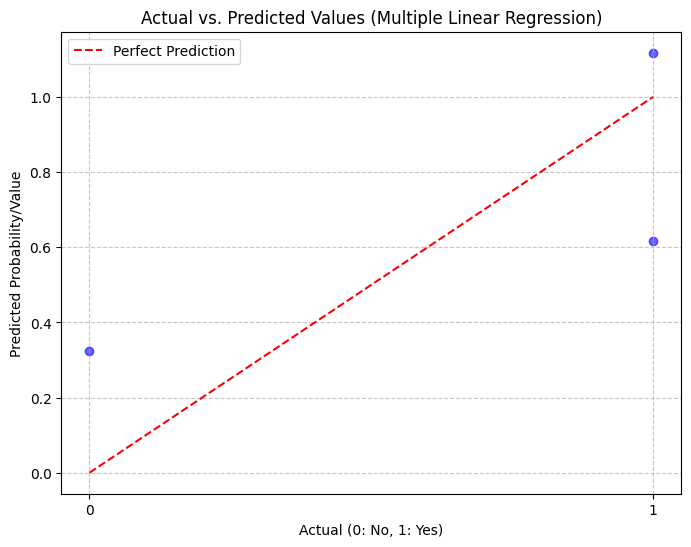

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([0, 1], [0, 1], 'r--', label='Perfect Prediction')
plt.xlabel('Actual (0: No, 1: Yes)')
plt.ylabel('Predicted Probability/Value')
plt.title('Actual vs. Predicted Values (Multiple Linear Regression)')
plt.xticks([0, 1])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

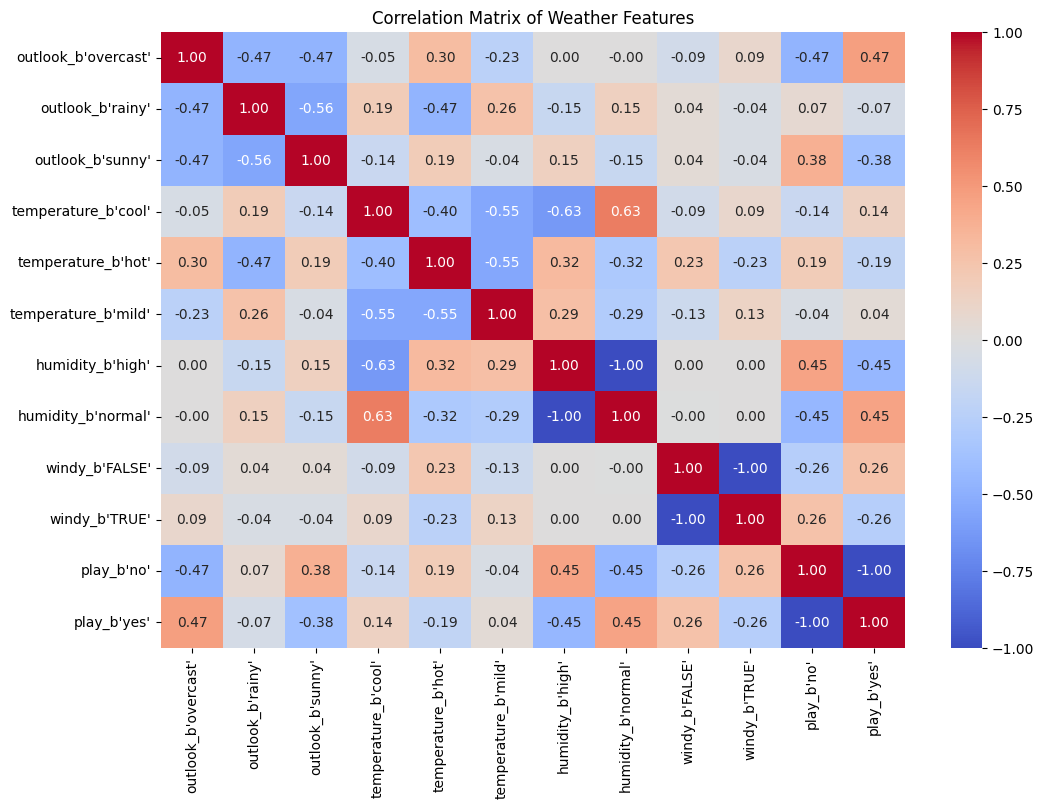

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix for the encoded data
plt.figure(figsize=(12, 8))
correlation_matrix = encoded_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Weather Features')
plt.show()

F1 Score: 1.0000


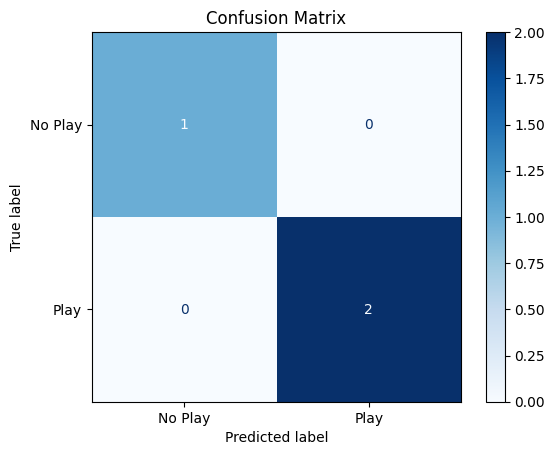

In [25]:
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay

# Binarize predictions (since regression gives continuous values)
# We use 0.5 as the threshold
y_pred_binary = (y_pred >= 0.5)

# Calculate F1-score
f1 = f1_score(y_test, y_pred_binary)
print(f"F1 Score: {f1:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Play', 'Play'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()